In [1]:
import MotifCompendium
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [2]:
MotifCompendium.set_compute_options(max_cpus=4, progress_bar=True, max_chunk=1152, use_gpu=True)

In [3]:
maindir = "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/"
modisco_dict = {
    "GM12878_counts": maindir+"GM12878/merge_folds_new_may_05_24/counts/modisco_counts.h5",
    "K562_counts": maindir+"K562/merge_folds_new_may_05_24/counts/modisco_counts.h5",
     "HEPG2_counts": maindir+"HEPG2/merge_folds_new_may_05_24/counts/modisco_counts.h5",
     "IMR90_counts": maindir+"IMR90/merge_folds_new_may_05_24/counts/modisco_counts.h5",
     "H1ESC_counts": maindir+"H1ESC/merge_folds_new_may_05_24/counts/modisco_counts.h5",    
}
mc = MotifCompendium.build_from_modisco(modisco_dict, modisco_region_width=500)
mc

computing similarities on GPU...: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.95s/it]


,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit
0,GM12878_counts-pos.pattern_0,33945,GM12878_counts,pos,0.558627,54.684254
1,GM12878_counts-pos.pattern_1,31055,GM12878_counts,pos,0.734233,24.672742
2,GM12878_counts-pos.pattern_10,3366,GM12878_counts,pos,0.464393,62.898693
3,GM12878_counts-pos.pattern_11,2489,GM12878_counts,pos,0.445151,52.124548
4,GM12878_counts-pos.pattern_12,2315,GM12878_counts,pos,0.450819,64.341253
...,...,...,...,...,...,...
286,H1ESC_counts-pos.pattern_9,2918,H1ESC_counts,pos,0.407995,44.774846
287,H1ESC_counts-neg.pattern_0,49,H1ESC_counts,neg,-0.180721,59.877551
288,H1ESC_counts-neg.pattern_1,43,H1ESC_counts,neg,-0.146924,60.209302
289,H1ESC_counts-neg.pattern_2,32,H1ESC_counts,neg,-0.204394,67.968750


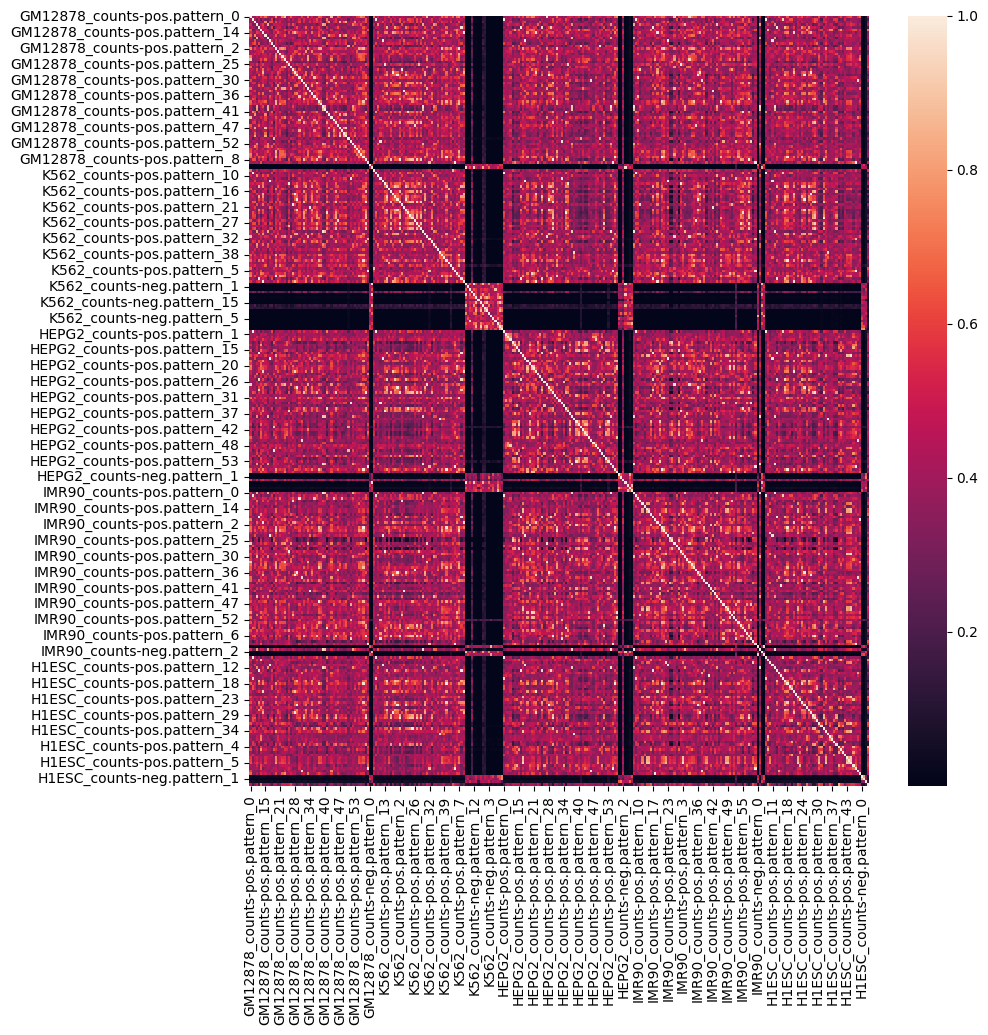

In [4]:
mc.heatmap(show=True, label=True)

In [5]:
import MotifCompendium.utils.analysis as utils_analysis

In [10]:
utils_analysis.plot_similarity_distribution(
    mc, "chrombpnet_outputs_counts/similarity_distribution.html"
)

In [11]:
mc.cluster(similarity_threshold=0.97)
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster
0,GM12878_counts-pos.pattern_0,33945,GM12878_counts,pos,0.558627,54.684254,96
1,GM12878_counts-pos.pattern_1,31055,GM12878_counts,pos,0.734233,24.672742,0
2,GM12878_counts-pos.pattern_10,3366,GM12878_counts,pos,0.464393,62.898693,95
3,GM12878_counts-pos.pattern_11,2489,GM12878_counts,pos,0.445151,52.124548,98
4,GM12878_counts-pos.pattern_12,2315,GM12878_counts,pos,0.450819,64.341253,2
...,...,...,...,...,...,...,...
286,H1ESC_counts-pos.pattern_9,2918,H1ESC_counts,pos,0.407995,44.774846,29
287,H1ESC_counts-neg.pattern_0,49,H1ESC_counts,neg,-0.180721,59.877551,223
288,H1ESC_counts-neg.pattern_1,43,H1ESC_counts,neg,-0.146924,60.209302,224
289,H1ESC_counts-neg.pattern_2,32,H1ESC_counts,neg,-0.204394,67.968750,225


In [12]:
# len(set(mc['cluster']))
# 574 clusters

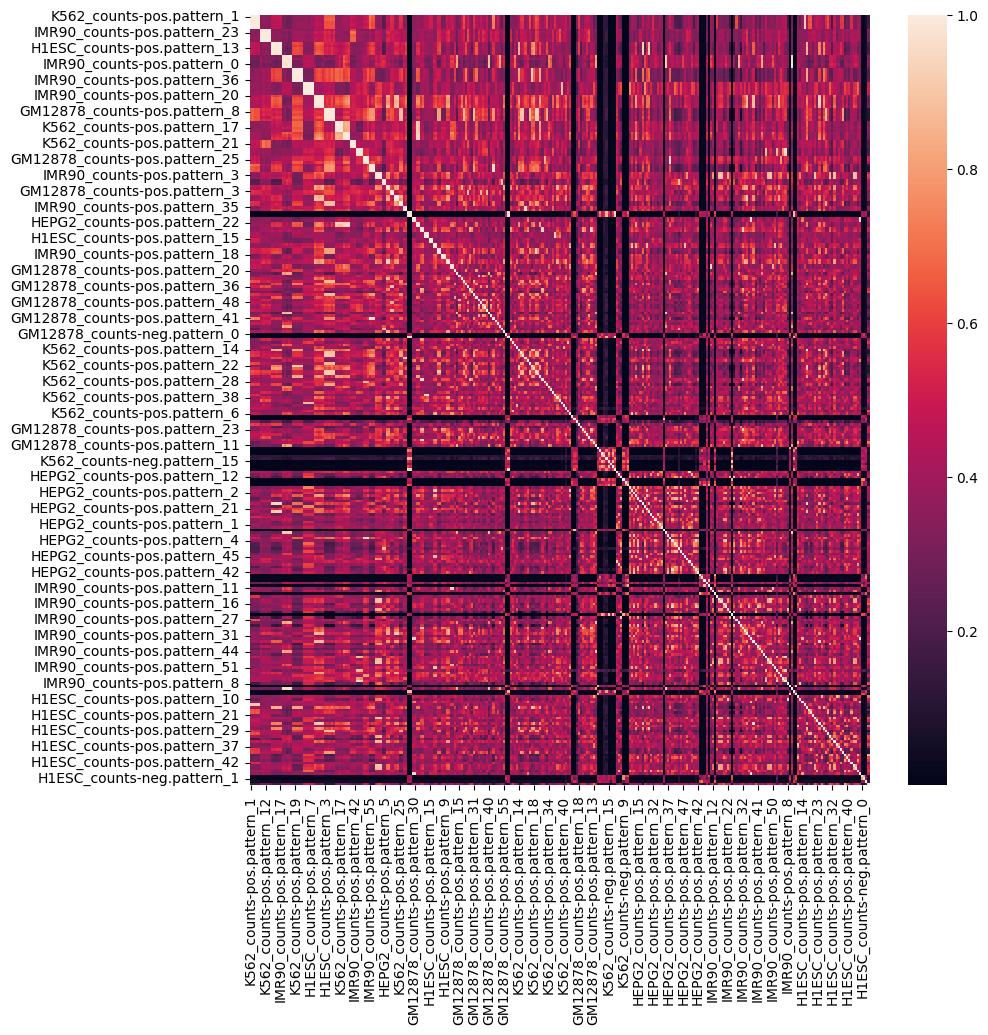

In [13]:
mc.sort(by="cluster").heatmap(show=True, label=True)

In [28]:
mc.motif_collection_html("chrombpnet_outputs_counts/motif_collection.html", "cluster")

In [14]:
mc_avg = mc.cluster_averages("cluster")
mc_avg

computing similarities on GPU...: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 69.97it/s]


,name,source_cluster,num_constituents
0,cluster#0,0,5
1,cluster#1,1,5
2,cluster#2,2,5
3,cluster#3,3,5
4,cluster#4,4,5
...,...,...,...
222,cluster#222,222,1
223,cluster#223,223,1
224,cluster#224,224,1
225,cluster#225,225,1


In [16]:
mc.save("chrombpnet_outputs_counts/motif_compendium.mc")
mc_avg.save("chrombpnet_outputs_counts/motif_compendium_average.mc")

In [15]:
mc_avg.add_motif_strings()
mc_avg

,name,source_cluster,num_constituents,motif_string
0,cluster#0,0,5,CGCCCCCT-G-GG<br/>CC-C-AGGGGGCG
1,cluster#1,1,5,G-----TGGGA--TGTAGT<br/>ACTACA--TCCCA-----C
2,cluster#2,2,5,GCGCA-GCGC<br/>GCGC-TGCGC
3,cluster#3,3,5,TGAGTCA<br/>TGACTCA
4,cluster#4,4,5,T-TCGCGA-A<br/>T-TCGCGA-A
...,...,...,...,...
222,cluster#222,222,1,GTTGCCATGG--AC<br/>GT--CCATGGCAAC
223,cluster#223,223,1,CAT--TG--C<br/>G--CA--ATG
224,cluster#224,224,1,TGT-CA<br/>TG-ACA
225,cluster#225,225,1,AT-T----T-T<br/>A-A----A-AT


In [31]:
mc_avg.summary_table_html("chrombpnet_outputs_counts/cluster_summary_table.html")

In [45]:
output_path= "/oak/stanford/groups/akundaje/cmyun/motifcompendium/tfatlas/encode/pipeline/counts/pipeline_counts_intarget-0.88-meta0.88-rec-force0.92/motifcompendium_avg_filtered.mc"

mc_3 = MotifCompendium.load(output_path, safe=True)


In [46]:
mc_3

,name,source_cluster,num_motifs,num_seqlets,model,avg_contrib,target,family,biosample,Within-target-cpm_leiden_0.88-rec-force0.92,...,reference_score2,reference_name2,flag_remove,weighted_base_entropy,truncated,dinuc_entropy_ratio,motif_entropy,posneg_inverted,copair_entropy_ratio,posbase_entropy_ratio
0,Within-target-cpm_leiden_0.88-rec-force0.92#2485,2485,1,25,ENCSR000BMJ_counts,0.031172,BCL11A,BCL,H1,2485,...,0.0,,False,0.434448,False,0.718863,0.724972,False,0.798567,0.910229
1,Within-target-cpm_leiden_0.88-rec-force0.92#1690,1690,1,170,ENCSR756UNW_counts,0.146336,ZNF548,ZNF,HepG2,1690,...,0.0,,False,0.343108,False,1.105385,0.672616,False,0.850557,1.111455
2,Within-target-cpm_leiden_0.88-rec-force0.92#1926,1926,1,879,ENCSR640STN_counts,0.368338,ZNF184,ZNF,WTC11,1926,...,0.0,,False,0.412521,False,0.707213,0.662858,False,0.775193,1.020513
3,Within-target-cpm_leiden_0.88-rec-force0.92#8874,8874,1,425,ENCSR967QUQ_counts,0.520762,CTCF,CTCF,dorsolateral prefrontal cortex,8874,...,0.0,,False,0.389484,False,0.827368,0.707698,False,0.979964,1.196991
4,Within-target-cpm_leiden_0.88-rec-force0.92#5108,5108,1,440,ENCSR175SZH_counts,0.407326,ZSCAN29,ZSCAN,K562,5108,...,0.0,,False,0.255262,False,0.691623,0.618890,False,0.764841,0.777275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9883,Within-target-cpm_leiden_0.88-rec-force0.92#8872,8872,86,34980,"ENCSR000ATN_counts,ENCSR000DMC_counts,ENCSR003...",0.566382,CTCF,CTCF,"CD14-positive monocyte,Peyer's patch,ascending...",8872,...,0.0,,False,0.375656,False,0.968232,0.714036,False,0.939740,1.210339
9884,Within-target-cpm_leiden_0.88-rec-force0.92#8825,8825,148,199501,"ENCSR000AKO_counts,ENCSR000ALA_counts,ENCSR000...",1.268808,CTCF,CTCF,"A549,AG09319,B cell,BE2C,CD14-positive monocyt...",8825,...,0.0,,False,0.251745,False,0.747209,0.609935,False,0.757499,0.893797
9885,Within-target-cpm_leiden_0.88-rec-force0.92#8817,8817,161,49560,"ENCSR000ALJ_counts,ENCSR000ALV_counts,ENCSR000...",1.421576,CTCF,CTCF,"A549,A673,AG09309,C4-2B,CD14-positive monocyte...",8817,...,0.0,,False,0.211114,False,0.930577,0.592618,False,0.771016,0.965841
9886,Within-target-cpm_leiden_0.88-rec-force0.92#8845,8845,354,237308,"ENCSR000AKB_counts,ENCSR000ALA_counts,ENCSR000...",0.583875,CTCF,CTCF,"22Rv1,A549,A673,AG04449,AG04450,AG09319,AG1080...",8845,...,0.0,,False,0.418056,False,1.130907,0.714912,False,1.118359,1.220099


In [42]:
mc_2

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,file,ID,target,biosample,family,invitro_ref,reference_score0,reference_name0,reference_score1,reference_name1,reference_score2,reference_name2
0,ENCSR440VKE_counts-pos.ENCSR440VKE_ChIP_ADNP_K...,4973,ENCSR440VKE_counts,pos,0.456629,70.113614,ENCSR440VKE_counts,ENCSR440VKE,ADNP,K562,ADNP,NaN,0.893848,HOCO.HSF1.H13CORE.2.P.B,0.000000,,0.0,
1,ENCSR440VKE_counts-pos.ENCSR440VKE_ChIP_ADNP_K...,4930,ENCSR440VKE_counts,pos,1.050016,43.765112,ENCSR440VKE_counts,ENCSR440VKE,ADNP,K562,ADNP,NaN,0.000000,,0.000000,,0.0,
2,ENCSR440VKE_counts-pos.ENCSR440VKE_ChIP_ADNP_K...,158,ENCSR440VKE_counts,pos,0.400058,58.974684,ENCSR440VKE_counts,ENCSR440VKE,ADNP,K562,ADNP,NaN,0.924441,HOCO.HSF1.H13CORE.2.P.B,0.000000,,0.0,
3,ENCSR440VKE_counts-pos.ENCSR440VKE_ChIP_ADNP_K...,116,ENCSR440VKE_counts,pos,0.565875,42.344828,ENCSR440VKE_counts,ENCSR440VKE,ADNP,K562,ADNP,NaN,0.000000,,0.000000,,0.0,
4,ENCSR440VKE_counts-pos.ENCSR440VKE_ChIP_ADNP_K...,69,ENCSR440VKE_counts,pos,0.296562,62.637681,ENCSR440VKE_counts,ENCSR440VKE,ADNP,K562,ADNP,NaN,0.941142,HOCO.ZN623.H13CORE.0.P.C,0.000000,,0.0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33242,ENCSR428LOB_counts-pos.ENCSR428LOB_ChIP_ZZZ3_H...,402,ENCSR428LOB_counts,pos,0.116523,69.251244,ENCSR428LOB_counts,ENCSR428LOB,ZZZ3,HepG2,ZZZ,NaN,0.795206,CDBK.MBD3.FL@CHS@TOP1,0.000000,,0.0,
33243,ENCSR428LOB_counts-pos.ENCSR428LOB_ChIP_ZZZ3_H...,332,ENCSR428LOB_counts,pos,0.113686,71.496988,ENCSR428LOB_counts,ENCSR428LOB,ZZZ3,HepG2,ZZZ,NaN,0.809688,HOCO.MYCN.H13CORE.1.M.C,0.768554,CDBK.KDM2A.FL@HTS.LYS@TOP1,0.0,
33244,ENCSR428LOB_counts-pos.ENCSR428LOB_ChIP_ZZZ3_H...,304,ENCSR428LOB_counts,pos,0.114224,69.562500,ENCSR428LOB_counts,ENCSR428LOB,ZZZ3,HepG2,ZZZ,NaN,0.791880,HOCO.MYCN.H13CORE.1.M.C,0.805665,CDBK.KDM2A.FL@HTS.LYS@TOP1,0.0,
33245,ENCSR428LOB_counts-pos.ENCSR428LOB_ChIP_ZZZ3_H...,286,ENCSR428LOB_counts,pos,0.115236,71.213287,ENCSR428LOB_counts,ENCSR428LOB,ZZZ3,HepG2,ZZZ,NaN,0.777772,HOCO.ZBT14.H13CORE.0.P.C,0.000000,,0.0,


In [40]:
utils_analysis.assign_label_from_other_compendium(
    assign_to_mc=mc_avg,
    assign_from_mc=mc_2,
    save_col_prefix="chiptf",
    min_score=0.7,
    max_submotifs = 2
)
mc_avg

computing similarities on GPU...: 100%|█████████████████████████████████████████████████████████████████| 29/29 [00:04<00:00,  7.24it/s]


,name,source_cluster,num_constituents,motif_string,chiptf_score0,chiptf_name0,chiptf_score1,chiptf_name1
0,cluster#0,0,11,CCAATC<br/>GATTGG,0.996631,ENCSR000ECX_counts-pos.ENCSR000ECX_ChIP_RFX5_H...,0.0,
1,cluster#1,1,11,CCGGAAG<br/>CTTCCGG,0.996597,ENCSR562POI_counts-pos.ENCSR562POI_ChIP_THAP11...,0.0,
2,cluster#2,2,10,GCGCA-GCGC<br/>GCGC-TGCGC,0.990350,ENCSR230PTV_counts-pos.ENCSR230PTV_ChIP_ZBTB2_...,0.0,
3,cluster#3,3,10,CGCCCCCT-G-GG<br/>CC-C-AGGGGGCG,0.995572,ENCSR037GKL_counts-pos.ENCSR037GKL_ChIP_CTCF_s...,0.0,
4,cluster#4,4,10,T-TCGCGAGA<br/>TCTCGCGA-A,0.992802,ENCSR860UHK_counts-pos.ENCSR860UHK_ChIP_CBFB_G...,0.0,
...,...,...,...,...,...,...,...,...
569,cluster#569,569,1,CCACCCAAATCTCAT<br/>ATGAGATTTGGGTGG,0.000000,,0.0,
570,cluster#570,570,1,CTGTCC--GGT-CTGA<br/>TCAG-ACC--GGACAG,0.000000,,0.0,
571,cluster#571,571,1,GATA--GATA<br/>TATC--TATC,0.965052,ENCSR000DKA_counts-pos.ENCSR000DKA_ChIP_GATA2_...,0.0,
572,cluster#572,572,1,GGT-ACTTCC-G<br/>C-GGAAGT-ACC,0.896674,ENCSR550HCT_counts-pos.ENCSR550HCT_ChIP_KLF1_K...,0.0,


In [32]:
mc.save("chrombpnet_outputs/motif_compendium.mc")
mc_avg.save("chrombpnet_outputs/motif_compendium_average.mc")